# Simple Linear Regression from scratch
### Implementation using Ordinary Least Squares (OLS) and Numpy Vectorization

**Author:** Kush Pal  
**Date:** 13 May 2026  
**Objective:** To implement a simple linear regression engine from first principles, utilizing the mathematical foundations found in *An Introduction to Statistical Learning* (ISLP). This project avoids high-level machine learning libraries like scikit-learn to demonstrate a deep understanding of the underlying statistics and optimization techniques.

## 1. The Mathematical Model

The simple linear regression model takes one single predictor variable only to predict the Response .
$$ Y \approx \beta_0 + \beta_1X \tag{1} $$
where  
* Y is the Response
* X is the Predictor Variable
* $\beta_0,\beta_1$ are the parameters or model coefficients
 To fit the model we need to estimate the slope $\beta_1$ and intercept $\beta_0$ from the training data in order to predict the response for future data.
Predictions will be given by the following equation 
$$\hat{y} = \hat{\beta_0} + \hat{\beta_1}x \tag{2}$$
* $\hat{y}$ is the prediction done when X = x
* $\hat{\beta_0} ,\hat{\beta_1} $ are the parameters value calculated on the training data
* x is the predictor variable value
### Residual Sum of Squares (RSS)


### Definition
While a line is fitted on a data. The Sum of Squared differences between the line and data points is called a Residual Sum of Squares. The difference itself is called a residual.

### Estimating Parameters
In order to estimate Parameters from training data we fit a straight line to the data using the least squares method .  
LEAST SQUARES METHOD works by calculating the RSS of the data and minimizing it . We take the parameters for which the RSS value is the least.


### RSS equation
$$RSS = \sum_{i=1}^{n} (y_i - \hat{y_i})^2 \tag{3}$$ <center>OR</center> $$RSS = \sum_{i=1}^{n} (y_i - (\hat{\beta_0} + \hat{\beta_1}x) )^2 \tag{4}$$

### The Closed Form Solution  
To minimize RSS we use Partial Derivatives on the RSS equation with respect to $\beta_0$ and $\beta_1$ and equating the partial derivatives to 0 in order to find the $\beta_0$ and $\beta_1$ . 
$$\frac{\partial (RSS)}{\partial (\beta_0)} = 0 \tag{5}$$ $$\frac{\partial (RSS)}{\partial (\beta_1)} = 0 \tag{6}$$
After solving the above equation we get the $\hat{\beta_0}$ and $\hat{\beta_1}$ for the model
$$ \hat{\beta_1} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2} \tag{7}$$
$$ \hat{\beta_0} = \bar{y} - \hat{\beta_1}\bar{x} \tag{8}$$
where  
* $\bar{y}$ is just the mean of y calculated using $\frac{1}{n}\sum_{i=1}^{n}y_i$
* $\bar{x}$ is just the mean of x calculated using $\frac{1}{n}\sum_{i=1}^{n}x_i$
After obtaining the parameters for least squares. The model is ready for predicting $\hat{y}$ using the equation number 2 given X = x.

In [1]:
import numpy as np

# Making the simple linear regression function from numpy vectorisation.

def Simple_Linear_Regression(X,Y):
    
    # Calculates mean for X and Y.
    a= np.mean(X)
    b= np.mean(Y)

    # Calculates terms for the slope using vectorisation to obtain O(1) efficiency instead of loop
    num = np.sum((X - a)*(Y - b))
    den = np.sum((X - a)**2)

    # Above can also be achieved throught the following loop as well
    # num = 0
    # den = 0

    # # for i in range(len(X)):
    # #     num = num + (X[i] - a)*(Y[i] - b)
    # #     den = den + (X[i] - a) ** 2

    # Final parameters
    slope = num/den
    intercept = b - slope*a

    return slope , intercept

print('Engine Created Successfully')

Engine Created Successfully


In [2]:
# Creating Synthetic data for testing 

# Setting a seed for reproducibility 
np.random.seed(42)

# Synthetic Population Parameters
true_slope  = 4.1
true_intercept = 5.3

# Generate Synthetic Data
X = 10*np.random.rand(100)
noise = np.random.randn(100)*2 #Gaussian Noise
Y = true_slope * X + true_intercept + noise

print(f"Generated 100 data points with the true slope = {true_slope} and true intercept = {true_intercept}.")


Generated 100 data points with the true slope = 4.1 and true intercept = 5.3.


In [3]:
# Testing the Engine 

# Slope and Intercept calculated on the basis of synthetic data.
m,c = Simple_Linear_Regression(X,Y)

print('-'*30)
print('RESULTS')
print('-'*30)
print(f"True Slope: {true_slope} | Model slope: {m:.4f}")
print(f"True Intercept: {true_intercept} | Model Intercept: {c:.4f}")



------------------------------
RESULTS
------------------------------
True Slope: 4.1 | Model slope: 4.0080
True Intercept: 5.3 | Model Intercept: 5.7302


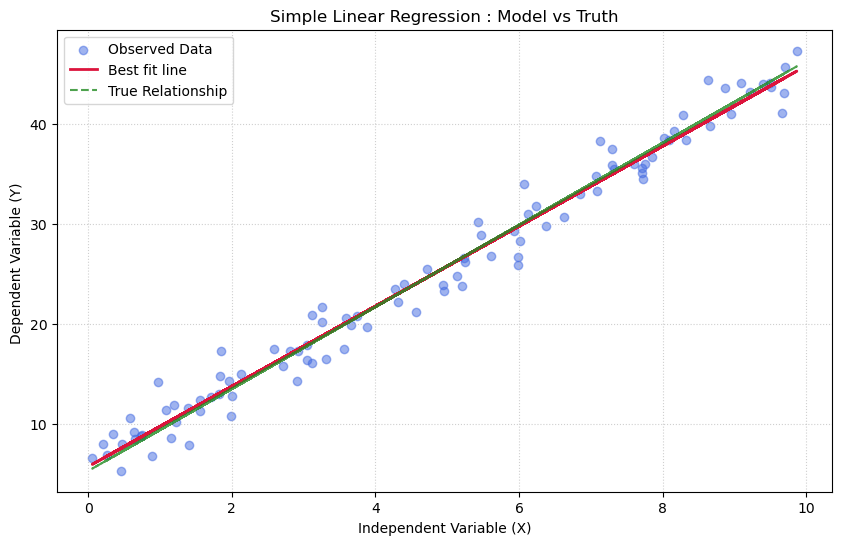

In [4]:
# Visualizing the Model

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Plotting Raw Data
plt.scatter(X,Y,label = 'Observed Data',color = 'royalblue',alpha = 0.5)

# Plotting Model Predictions
predicted_y = X*m + c
plt.plot(X,predicted_y,label= f'Best fit line',color = 'crimson',linewidth = 2)

# Plotting Population Truth
true_y = true_slope*X + true_intercept
plt.plot(X,true_y,color = 'forestgreen',label = 'True Relationship',alpha = 0.8,linestyle = '--')

plt.title('Simple Linear Regression : Model vs Truth')
plt.xlabel('Independent Variable (X)')
plt.ylabel('Dependent Variable (Y) ')
plt.legend()
plt.grid(True,linestyle = ':',alpha = 0.6)
plt.show()